# Regression

This notebook is the practical companion to the Regression chapter. It focuses on fitting regression models, interpreting coefficients, calculating fitted values and residuals, categorical predictors, interactions, and polynomial terms.


## 1. Learning Goals

- Fit a simple linear regression model.
- Calculate slope and intercept manually.
- Calculate fitted values and residuals.
- Visualise a regression line.
- Fit multiple regression.
- Encode categorical predictors.
- Create interaction terms.
- Fit a polynomial model.
- Compare predictions inside and outside the observed range.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


## 2. Create Simple Regression Data


In [2]:
df = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5],
    "marks": [42, 48, 55, 63, 70]
})

df


,study_hours,marks
0,1,42
1,2,48
2,3,55
3,4,63
4,5,70


## 3. Calculate the Slope and Intercept Manually


In [3]:
x = df["study_hours"].to_numpy(dtype=float)
y = df["marks"].to_numpy(dtype=float)

x_bar = x.mean()
y_bar = y.mean()

b1 = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar) ** 2)
b0 = y_bar - b1 * x_bar

print("x mean:", x_bar)
print("y mean:", y_bar)
print("Slope:", b1)
print("Intercept:", b0)


x mean: 3.0
y mean: 55.6
Slope: 7.1
Intercept: 34.300000000000004


## 4. Fit Simple Linear Regression With scikit-learn


In [4]:
X = df[["study_hours"]]
y = df["marks"]

model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])


Intercept: 34.29999999999999
Slope: 7.100000000000003


## 5. Generate Fitted Values


In [5]:
df["fitted_marks"] = model.predict(X)
df["residual"] = df["marks"] - df["fitted_marks"]

df


,study_hours,marks,fitted_marks,residual
0,1,42,41.4,0.6
1,2,48,48.5,-0.5
2,3,55,55.6,-0.6
3,4,63,62.7,0.3
4,5,70,69.8,0.2


## 6. Verify the Residual Sum


In [6]:
print("Sum of residuals:", df["residual"].sum())


Sum of residuals: -7.105427357601002e-15


## 7. Plot Observations and Regression Line


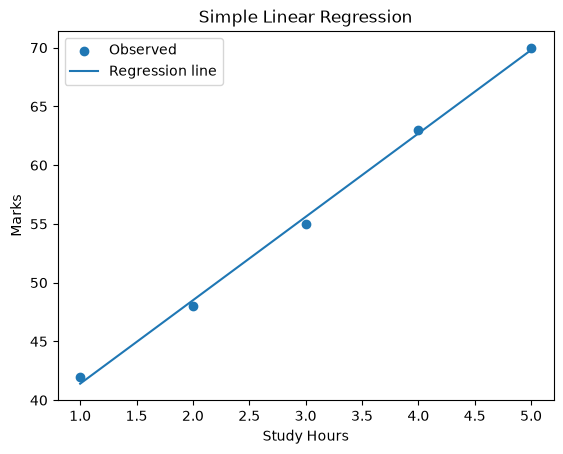

In [7]:
plt.scatter(df["study_hours"], df["marks"], label="Observed")
plt.plot(df["study_hours"], df["fitted_marks"], label="Regression line")
plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()


## 8. Make a Prediction


In [8]:
prediction = model.predict([[4]])
print("Predicted marks for 4 study hours:", prediction[0])


Predicted marks for 4 study hours: 62.7


C:\Users\zeesh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 9. Interpolation and Extrapolation

The observed predictor range is from 1 to 5 hours.


In [9]:
print("Prediction at X=3 (interpolation):", model.predict([[3]])[0])
print("Prediction at X=8 (extrapolation):", model.predict([[8]])[0])


Prediction at X=3 (interpolation): 55.6
Prediction at X=8 (extrapolation): 91.10000000000002


C:\Users\zeesh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\zeesh\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 10. Multiple Linear Regression


In [10]:
multi_df = pd.DataFrame({
    "study_hours": [2, 3, 4, 5, 6, 7, 8, 9],
    "attendance": [60, 65, 70, 72, 78, 82, 88, 92],
    "marks": [45, 50, 54, 61, 65, 70, 76, 84]
})

X_multi = multi_df[["study_hours", "attendance"]]
y_multi = multi_df["marks"]

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print("Intercept:", multi_model.intercept_)
print("Coefficients:", multi_model.coef_)


Intercept: 41.255555555555574
Coefficients: [ 6.12222222 -0.15555556]


## 11. Multiple Regression Prediction


In [11]:
new_student = pd.DataFrame({
    "study_hours": [5],
    "attendance": [80]
})

print("Predicted marks:", multi_model.predict(new_student)[0])


Predicted marks: 59.42222222222222


## 12. Categorical Predictor

Create a binary study-mode variable. The first category is treated as the reference group.


In [12]:
cat_df = pd.DataFrame({
    "study_hours": [2, 3, 4, 5, 6, 7],
    "study_mode": ["Online", "Online", "Offline", "Offline", "Online", "Offline"],
    "marks": [45, 49, 56, 63, 64, 72]
})

cat_encoded = pd.get_dummies(cat_df, columns=["study_mode"], drop_first=True, dtype=int)
cat_encoded


,study_hours,marks,study_mode_Online
0,2,45,1
1,3,49,1
2,4,56,0
3,5,63,0
4,6,64,1
5,7,72,0


## 13. Fit Regression With a Categorical Predictor


In [13]:
X_cat = cat_encoded[["study_hours", "study_mode_Online"]]
y_cat = cat_encoded["marks"]

cat_model = LinearRegression()
cat_model.fit(X_cat, y_cat)

print("Intercept:", cat_model.intercept_)
print("Coefficients:", cat_model.coef_)


Intercept: 37.266666666666666
Coefficients: [ 4.95 -2.75]


## 14. Interaction Term


In [14]:
interaction_df = pd.DataFrame({
    "study_hours": [2, 3, 4, 5, 6, 7],
    "offline": [0, 0, 1, 1, 0, 1],
    "marks": [45, 49, 56, 63, 64, 72]
})

interaction_df["study_hours_offline"] = (
    interaction_df["study_hours"] * interaction_df["offline"]
)

interaction_df


,study_hours,offline,marks,study_hours_offline
0,2,0,45,0
1,3,0,49,0
2,4,1,56,4
3,5,1,63,5
4,6,0,64,0
5,7,1,72,7


In [15]:
X_interaction = interaction_df[["study_hours", "offline", "study_hours_offline"]]
y_interaction = interaction_df["marks"]

interaction_model = LinearRegression()
interaction_model.fit(X_interaction, y_interaction)

print("Intercept:", interaction_model.intercept_)
print("Coefficients:", interaction_model.coef_)


Intercept: 35.03846153846155
Coefficients: [4.80769231 0.81868132 0.40659341]


## 15. Polynomial Regression


In [16]:
x_poly = np.arange(1, 9).reshape(-1, 1)
y_poly = np.array([5, 9, 14, 20, 29, 41, 56, 74])

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(x_poly)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_poly)

print("Intercept:", poly_model.intercept_)
print("Coefficients:", poly_model.coef_)


Intercept: 6.285714285714278
Coefficients: [ 0.         -1.52380952  1.23809524]


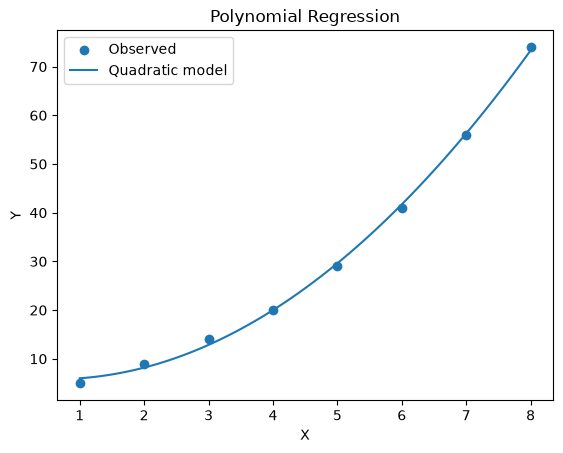

In [17]:
x_plot = np.linspace(1, 8, 100).reshape(-1, 1)
y_plot = poly_model.predict(poly.transform(x_plot))

plt.scatter(x_poly, y_poly, label="Observed")
plt.plot(x_plot, y_plot, label="Quadratic model")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression")
plt.legend()
plt.show()


## 16. Residual Visualisation

Residuals are the observed values minus fitted values. A residual plot can help reveal systematic patterns that a model may not capture.


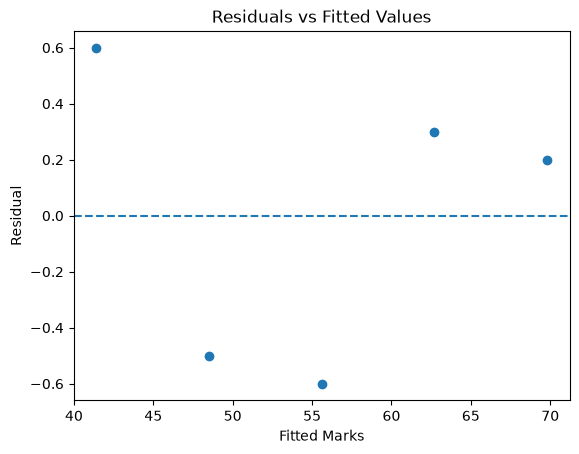

In [18]:
plt.scatter(df["fitted_marks"], df["residual"])
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Marks")
plt.ylabel("Residual")
plt.title("Residuals vs Fitted Values")
plt.show()


## 17. Practice Questions

1. Create a dataset with at least 8 paired observations and calculate the regression slope manually.
2. Calculate the intercept from the sample means.
3. Fit the same model with scikit-learn and compare the coefficients.
4. Calculate the fitted value and residual for every observation.
5. Plot the observations and regression line.
6. Explain the slope in the units of the original variables.
7. Create a multiple regression model with three predictors.
8. Create a categorical predictor with three categories and choose a reference category.
9. Add an interaction between a numerical predictor and a binary category.
10. Fit a quadratic regression model and explain why the relationship is curved.
11. Give one example of interpolation and one example of extrapolation.
12. Explain why a regression model does not automatically establish causation.


## 18. Final Practical Checklist

- Identify the response and predictor variables.
- Inspect the relationship before fitting the model.
- Calculate or inspect the fitted coefficients.
- Interpret the intercept only when $X=0$ is meaningful.
- Interpret the slope in the correct units.
- Calculate fitted values and residuals.
- Be cautious with extrapolation.
- For multiple regression, interpret coefficients while holding other predictors constant.
- Encode categorical variables appropriately.
- Use interaction terms only when the effect is expected to differ across conditions.
- Keep detailed model evaluation for Folder 11.
